part2/
│
├─ build_part2.py          # CLI/driver: streams train file → writes part2.txt
├─ corruptions.py          # the 5 corruption families (micro_typo, punct_space, ...)
├─ loaders.py              # load_char_lm(...), load_bpe_lm(...)
├─ nll.py                  # avg_nll_from_ids(...), make_char_nll(...), make_bpe_nll(...)
└─ constants.py            # paths, seeds, small knobs


In [1]:
%run part2.py

[resume] output → /notebooks/Modifier/part2.txt
[resume] lines already present: 541,768
[load] char LM …
[load] BPE  LM …
[build] reading A-sentences from train_utf8.txt
[550,000] lines written  |  elapsed=5.1 min
[560,000] lines written  |  elapsed=11.4 min
[570,000] lines written  |  elapsed=17.6 min
[580,000] lines written  |  elapsed=23.8 min
[590,000] lines written  |  elapsed=29.9 min
[600,000] lines written  |  elapsed=36.1 min
[610,000] lines written  |  elapsed=42.4 min
[620,000] lines written  |  elapsed=48.6 min
[630,000] lines written  |  elapsed=54.7 min
[640,000] lines written  |  elapsed=60.9 min
[650,000] lines written  |  elapsed=67.1 min
[660,000] lines written  |  elapsed=73.3 min
[670,000] lines written  |  elapsed=79.5 min
[680,000] lines written  |  elapsed=85.7 min
[690,000] lines written  |  elapsed=92.0 min
[700,000] lines written  |  elapsed=98.2 min
[710,000] lines written  |  elapsed=104.4 min
[720,000] lines written  |  elapsed=110.6 min
[730,000] lines wri

In [4]:
# audit_part2_small.py
import time
from pathlib import Path

from constants import OUT_PATH, DEVICE, CHAR_CKPT_DIR, BPE_CKPT_DIR
from loaders   import load_char_lm, load_bpe_lm
from nll       import make_char_nll, make_bpe_nll

# ---------- config ----------
FIRST_N = 2_000   # only read the first N lines of part2.txt
SHOW    = 20      # show top-K hardest (smallest positive Δ)

def main():
    part2 = Path(OUT_PATH)
    if not part2.exists():
        raise FileNotFoundError(f"{OUT_PATH} not found")

    print("[load] char LM …")
    ch_model, ch_encode, ch_block = load_char_lm(CHAR_CKPT_DIR, device=DEVICE)
    ch_model.eval()
    char_nll = make_char_nll(ch_model, ch_encode, ch_block, DEVICE)

    print("[load] BPE  LM …")
    bp_model, bp_encode, bp_block, _ = load_bpe_lm(BPE_CKPT_DIR, device=DEVICE)
    bp_model.eval()
    bpe_nll = make_bpe_nll(bp_model, bp_encode, bp_block, DEVICE)

    kept = []  # (delta, ln_no, A, B, used_char, nllA, nllB)
    seen = 0
    t0 = time.time()

    print(f"[scan] reading first {FIRST_N:,} lines from {part2}")
    with open(part2, "r", encoding="utf-8", errors="replace") as f:
        for ln_no, line in enumerate(f, 1):
            if seen >= FIRST_N: break
            if "\t" not in line: 
                continue
            A, B = line.rstrip("\n").split("\t", 1)

            # parity rule: builder used even output lines -> char, odd -> bpe
            used_char = (ln_no % 2 == 0)
            scorer = char_nll if used_char else bpe_nll

            nlla = scorer(A)
            nllb = scorer(B)
            kept.append((nllb - nlla, ln_no, A, B, used_char, nlla, nllb))
            seen += 1

    if not kept:
        print("No A\\tB lines found in the inspected range.")
        return

    # summarize
    deltas = sorted(x[0] for x in kept)
    gt0 = [d for d in deltas if d > 0]
    le0 = [d for d in deltas if d <= 0]
    print("\n[summary]")
    print(f"inspected pairs: {seen:,}")
    print(f"Δ<=0 (model prefers B or tie): {len(le0):,}")
    print(f"Δ>0  (as intended):             {len(gt0):,}")

    # hardest = smallest positive Δ
    hardest = [row for row in kept if row[0] > 0]
    hardest.sort(key=lambda x: x[0])

    print(f"\n[hardest {min(SHOW,len(hardest))}] (smallest positive Δ = NLL(B)-NLL(A))")
    for k, (delta, ln_no, A, B, used_char, nlla, nllb) in enumerate(hardest[:SHOW], 1):
        tag = "char" if used_char else "bpe "
        print(f"\n#{k} line={ln_no:,}  Δ={delta:.4f}  ({tag})  nllA={nlla:.4f}  nllB={nllb:.4f}")
        print("A:", A[:240])
        print("B:", B[:240])

    if le0:
        print(f"\n[note] Showing a few Δ<=0 examples (model likes B >= A):")
        bad = [row for row in kept if row[0] <= 0]
        bad.sort(key=lambda x: x[0])  # most negative first
        for k, (delta, ln_no, A, B, used_char, nlla, nllb) in enumerate(bad[:min(10,len(bad))], 1):
            tag = "char" if used_char else "bpe "
            print(f"\n#{k} line={ln_no:,}  Δ={delta:.4f}  ({tag})  nllA={nlla:.4f}  nllB={nllb:.4f}")
            print("A:", A[:240])
            print("B:", B[:240])

if __name__ == "__main__":
    main()


[load] char LM …
[load] BPE  LM …
[scan] reading first 2,000 lines from part2.txt

[summary]
inspected pairs: 2,000
Δ<=0 (model prefers B or tie): 0
Δ>0  (as intended):             2,000

[hardest 20] (smallest positive Δ = NLL(B)-NLL(A))

#1 line=336  Δ=0.0001  (char)  nllA=1.0415  nllB=1.0416
A: In the subtle backdrop of the Indian freedom movement , it is the story of the transformation of a young boy 's innocent but naughty childhood to an appreciation of the Swadeshi movement and the growth of adolescent love for a girl even you
B: In the subtle backdrop of the Indian freedom movement, it is the story of the transformation of a young boy 's innocent but naughty childhood to an appreciation of the Swadeshi movement and the growth of adolescent love for a girl even youn

#2 line=1,278  Δ=0.0002  (char)  nllA=1.2264  nllB=1.2266
A: Two incidents attract Diego 's attention : a group of boys causing mischief to corrupt merchants leaving behind a chalked `` Z '' , and a monk named Broth

[load] char LM …
[load] BPE  LM …
[scan] reading first 5000 lines from part2.txt (EVERY=1)
  [5,000] scored…
[stats] pairs=5,000  Δ<=0: 0  Δ>0: 5,000  meanΔ=0.1232  time=91.5s


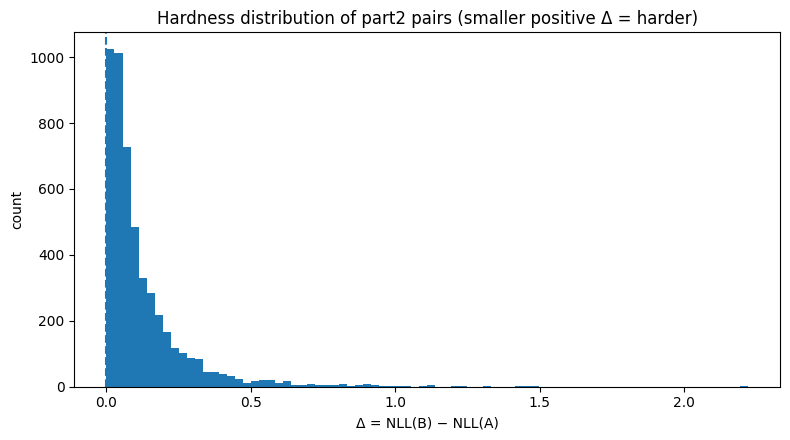

In [5]:
# plot_deltas.py
import time
from pathlib import Path
import matplotlib.pyplot as plt

from constants import OUT_PATH, DEVICE, CHAR_CKPT_DIR, BPE_CKPT_DIR
from loaders   import load_char_lm, load_bpe_lm
from nll       import make_char_nll, make_bpe_nll

# ---------- config ----------
FIRST_N = 5_000   # only inspect the first N A\tB pairs (set None to scan all)
EVERY   = 1       # sample every k-th line to go faster (e.g., 5 or 10)
BINS    = 80      # histogram bins

def main():
    part2 = Path(OUT_PATH)
    if not part2.exists():
        raise FileNotFoundError(f"{OUT_PATH} not found")

    print("[load] char LM …")
    ch_model, ch_encode, ch_block = load_char_lm(CHAR_CKPT_DIR, device=DEVICE)
    ch_model.eval()
    char_nll = make_char_nll(ch_model, ch_encode, ch_block, DEVICE)

    print("[load] BPE  LM …")
    bp_model, bp_encode, bp_block, _ = load_bpe_lm(BPE_CKPT_DIR, device=DEVICE)
    bp_model.eval()
    bpe_nll = make_bpe_nll(bp_model, bp_encode, bp_block, DEVICE)

    deltas = []
    seen   = 0
    t0     = time.time()

    print(f"[scan] reading {('first '+str(FIRST_N)) if FIRST_N else 'all'} lines from {part2} (EVERY={EVERY})")
    with open(part2, "r", encoding="utf-8", errors="replace") as f:
        for ln_no, line in enumerate(f, 1):
            if "\t" not in line:
                continue
            if EVERY > 1 and (ln_no % EVERY) != 0:
                continue
            if FIRST_N is not None and seen >= FIRST_N:
                break

            A, B = line.rstrip("\n").split("\t", 1)

            # parity: even output lines were scored by char LM, odd by BPE
            used_char = (ln_no % 2 == 0)
            scorer    = char_nll if used_char else bpe_nll

            nlla = scorer(A)
            nllb = scorer(B)
            deltas.append(nllb - nlla)
            seen += 1

            if seen % 500 == 0:
                print(f"  [{seen:,}] scored…", end="\r")

    dt = time.time() - t0
    if not deltas:
        print("No valid A\\tB lines were found in the inspected range.")
        return

    # quick stats
    le0 = sum(1 for d in deltas if d <= 0)
    gt0 = len(deltas) - le0
    mean = sum(deltas)/len(deltas)
    print(f"\n[stats] pairs={len(deltas):,}  Δ<=0: {le0:,}  Δ>0: {gt0:,}  meanΔ={mean:.4f}  time={dt:.1f}s")

    # histogram
    plt.figure(figsize=(8, 4.5))
    plt.hist(deltas, bins=BINS)
    plt.axvline(0.0, linestyle="--")
    plt.xlabel("Δ = NLL(B) − NLL(A)")
    plt.ylabel("count")
    plt.title("Hardness distribution of part2 pairs (smaller positive Δ = harder)")
    plt.tight_layout()
    # Optional: save as file
    # plt.savefig("delta_hist.png", dpi=150)
    plt.show()

if __name__ == "__main__":
    main()


[load] char LM …
[load] BPE  LM …
[scan] first 30000 lines from part2.txt (EVERY=1)
  [30,000] scored…
[stats] pairs=30,000  Δ<=0: 2  (0.01%)  Δ>0: 29,998
        minΔ=-0.3968  q10=0.0128  q50=0.0722  q90=0.2885  maxΔ=2.5776
        meanΔ=0.1222  time=545.2s


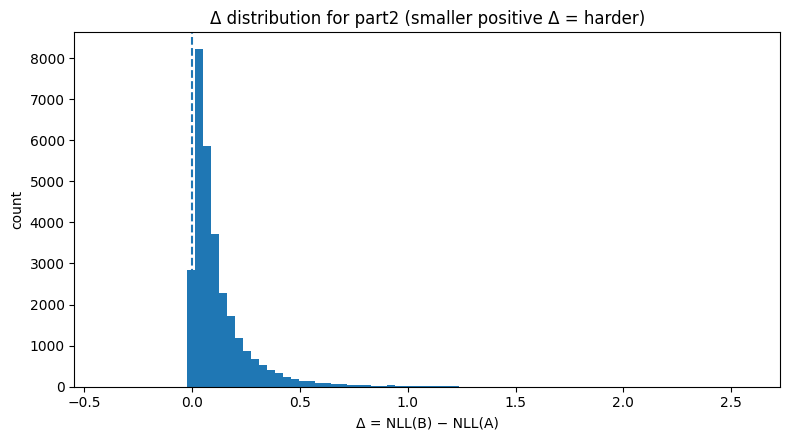

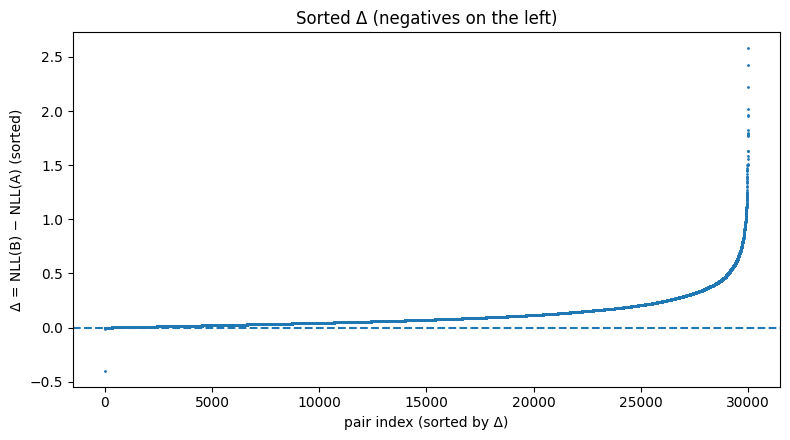


[examples] Top 2 most negative Δ (model prefers B):

#1  line=9001  Δ=-0.3968
A: good uh let's see so uh were we right in the Middle East
B: good uh let's see so uh were we right in the Middle East .

#2  line=27489  Δ=-0.0162
A: To what extent are we maintaining more than just superficial contact with government bodies?
B: To what extent are we maintaining more than just superficial contact with government bodies? .


In [7]:
# plot_deltas_full.py
import time
from pathlib import Path
import matplotlib.pyplot as plt

from constants import OUT_PATH, DEVICE, CHAR_CKPT_DIR, BPE_CKPT_DIR
from loaders   import load_char_lm, load_bpe_lm
from nll       import make_char_nll, make_bpe_nll

# -------- config --------
FIRST_N   = 30_000   # inspect first N pairs; set to None to scan all
EVERY     = 1        # sample every k-th line (e.g., 5 or 10 for speed)
NEG_SHOW  = 5        # print this many most-negative examples
HIST_BINS = 80

def main():
    part2 = Path(OUT_PATH)
    if not part2.exists():
        raise FileNotFoundError(f"{OUT_PATH} not found")

    print("[load] char LM …")
    ch_model, ch_encode, ch_block = load_char_lm(CHAR_CKPT_DIR, device=DEVICE)
    ch_model.eval()
    char_nll = make_char_nll(ch_model, ch_encode, ch_block, DEVICE)

    print("[load] BPE  LM …")
    bp_model, bp_encode, bp_block, _ = load_bpe_lm(BPE_CKPT_DIR, device=DEVICE)
    bp_model.eval()
    bpe_nll = make_bpe_nll(bp_model, bp_encode, bp_block, DEVICE)

    deltas = []
    neg_buf = []  # (delta, ln_no, A, B)
    seen   = 0
    t0     = time.time()

    print(f"[scan] {('first '+str(FIRST_N)) if FIRST_N else 'all'} lines from {part2} (EVERY={EVERY})")
    with open(part2, "r", encoding="utf-8", errors="replace") as f:
        for ln_no, line in enumerate(f, 1):
            if "\t" not in line:
                continue
            if EVERY > 1 and (ln_no % EVERY) != 0:
                continue
            if FIRST_N is not None and seen >= FIRST_N:
                break

            A, B = line.rstrip("\n").split("\t", 1)
            use_char = (ln_no % 2 == 0)
            scorer   = char_nll if use_char else bpe_nll

            nlla = scorer(A)
            nllb = scorer(B)
            d = nllb - nlla
            deltas.append(d)
            if d <= 0:
                neg_buf.append((d, ln_no, A, B))
            seen += 1

            if seen % 500 == 0:
                print(f"  [{seen:,}] scored…", end="\r")

    dt = time.time() - t0
    if not deltas:
        print("No valid A\\tB lines found in the inspected range.")
        return

    # ---------- stats ----------
    n = len(deltas)
    le0 = sum(1 for d in deltas if d <= 0)
    gt0 = n - le0
    mean = sum(deltas)/n
    srt  = sorted(deltas)
    def q(p):
        i = max(0, min(n-1, int(p*(n-1))))
        return srt[i]
    print(f"\n[stats] pairs={n:,}  Δ<=0: {le0:,}  ({le0/n*100:.2f}%)  Δ>0: {gt0:,}")
    print(f"        minΔ={srt[0]:.4f}  q10={q(0.10):.4f}  q50={q(0.50):.4f}  q90={q(0.90):.4f}  maxΔ={srt[-1]:.4f}")
    print(f"        meanΔ={mean:.4f}  time={dt:.1f}s")

    # ---------- histogram ----------
    plt.figure(figsize=(8, 4.5))
    plt.hist(deltas, bins=HIST_BINS)
    plt.axvline(0.0, linestyle="--")
    plt.xlabel("Δ = NLL(B) − NLL(A)")
    plt.ylabel("count")
    plt.title("Δ distribution for part2 (smaller positive Δ = harder)")
    plt.tight_layout()
    # plt.savefig("delta_hist.png", dpi=150)
    plt.show()

    # ---------- sorted Δ plot ----------
    plt.figure(figsize=(8, 4.5))
    xs = srt
    plt.plot(xs, ".", markersize=2)
    plt.axhline(0.0, linestyle="--")
    plt.ylabel("Δ = NLL(B) − NLL(A) (sorted)")
    plt.xlabel("pair index (sorted by Δ)")
    plt.title("Sorted Δ (negatives on the left)")
    plt.tight_layout()
    # plt.savefig("delta_sorted.png", dpi=150)
    plt.show()

    # ---------- print a few most-negative examples ----------
    if neg_buf:
        neg_buf.sort(key=lambda t: t[0])  # most negative first
        k = min(NEG_SHOW, len(neg_buf))
        print(f"\n[examples] Top {k} most negative Δ (model prefers B):")
        for i in range(k):
            d, ln, A, B = neg_buf[i]
            print(f"\n#{i+1}  line={ln}  Δ={d:.4f}")
            print("A:", A)
            print("B:", B)
    else:
        print("\n[examples] No Δ ≤ 0 found in the inspected slice.")

if __name__ == "__main__":
    main()


[load] char LM …
[load] BPE  LM …
[scan] first 30000 lines from train_utf8.txt (EVERY=1)
  [30,000] scored…
[stats] pairs=30,000  Δ<=0: 2,211  (7.37%)  Δ>0: 27,789
        minΔ=-1.2730  q10=0.0142  q50=0.1433  q90=0.5641  maxΔ=4.3460
        meanΔ=0.2310  time=539.2s


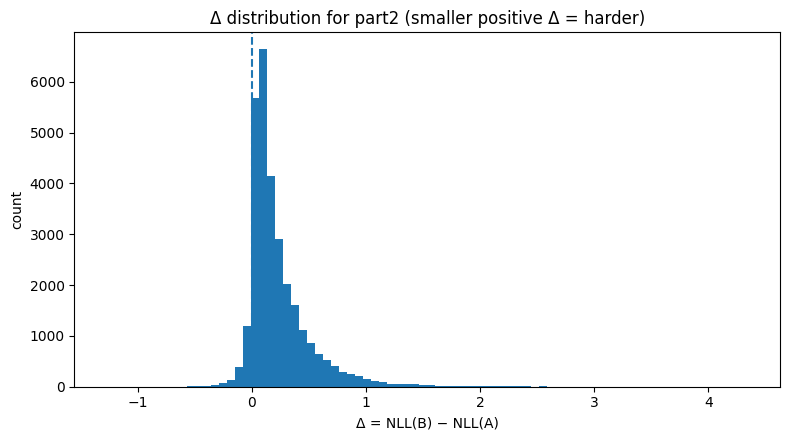

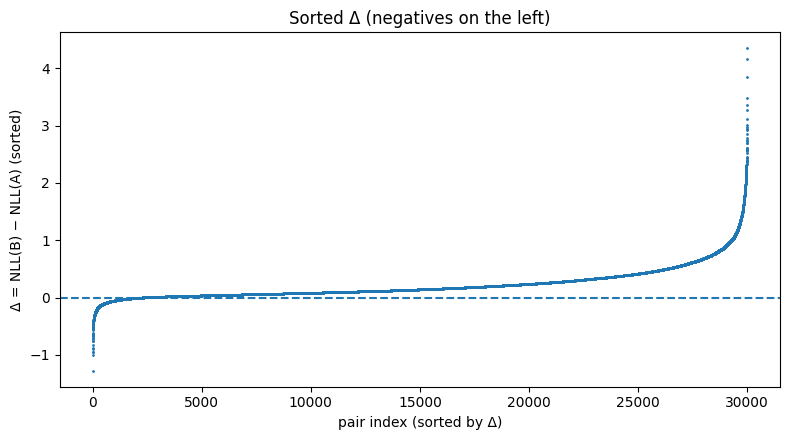


[examples] Top 5 most negative Δ (model prefers B):

#1  line=19324  Δ=-1.2730
A: http:\/\/movies.nytimes.com\/movie\/361895\/In-3-Tagen-Bist-Du-Tot\/overview
B: Charlie

#2  line=8651  Δ=-1.0078
A: Laura ignores him and marries Glyde .
B: Laura ignores him and marries Paul .

#3  line=9503  Δ=-0.9438
A: As they get off the mountain , the last pterodactyl attacks .
B: As they get off the mountain , the last friend attacks .

#4  line=14347  Δ=-0.9433
A: who's the who's the author
B: who's the who's author 

#5  line=7863  Δ=-0.8997
A: Shh, she said.
B: because she said.


In [8]:
# plot_deltas_full.py
import time
from pathlib import Path
import matplotlib.pyplot as plt

from constants import TRAIN_PATHS, DEVICE, CHAR_CKPT_DIR, BPE_CKPT_DIR
from loaders   import load_char_lm, load_bpe_lm
from nll       import make_char_nll, make_bpe_nll

# -------- config --------
FIRST_N   = 30_000   # inspect first N pairs; set to None to scan all
EVERY     = 1        # sample every k-th line (e.g., 5 or 10 for speed)
NEG_SHOW  = 5        # print this many most-negative examples
HIST_BINS = 80
TRAIN_PATH = TRAIN_PATHS[0]
def main():
    part2 = Path(TRAIN_PATH)
    if not part2.exists():
        raise FileNotFoundError(f"{TRAIN_PATH} not found")

    print("[load] char LM …")
    ch_model, ch_encode, ch_block = load_char_lm(CHAR_CKPT_DIR, device=DEVICE)
    ch_model.eval()
    char_nll = make_char_nll(ch_model, ch_encode, ch_block, DEVICE)

    print("[load] BPE  LM …")
    bp_model, bp_encode, bp_block, _ = load_bpe_lm(BPE_CKPT_DIR, device=DEVICE)
    bp_model.eval()
    bpe_nll = make_bpe_nll(bp_model, bp_encode, bp_block, DEVICE)

    deltas = []
    neg_buf = []  # (delta, ln_no, A, B)
    seen   = 0
    t0     = time.time()

    print(f"[scan] {('first '+str(FIRST_N)) if FIRST_N else 'all'} lines from {part2} (EVERY={EVERY})")
    with open(part2, "r", encoding="utf-8", errors="replace") as f:
        for ln_no, line in enumerate(f, 1):
            if "\t" not in line:
                continue
            if EVERY > 1 and (ln_no % EVERY) != 0:
                continue
            if FIRST_N is not None and seen >= FIRST_N:
                break

            A, B = line.rstrip("\n").split("\t", 1)
            use_char = (ln_no % 2 == 0)
            scorer   = char_nll if use_char else bpe_nll

            nlla = scorer(A)
            nllb = scorer(B)
            d = nllb - nlla
            deltas.append(d)
            if d <= 0:
                neg_buf.append((d, ln_no, A, B))
            seen += 1

            if seen % 500 == 0:
                print(f"  [{seen:,}] scored…", end="\r")

    dt = time.time() - t0
    if not deltas:
        print("No valid A\\tB lines found in the inspected range.")
        return

    # ---------- stats ----------
    n = len(deltas)
    le0 = sum(1 for d in deltas if d <= 0)
    gt0 = n - le0
    mean = sum(deltas)/n
    srt  = sorted(deltas)
    def q(p):
        i = max(0, min(n-1, int(p*(n-1))))
        return srt[i]
    print(f"\n[stats] pairs={n:,}  Δ<=0: {le0:,}  ({le0/n*100:.2f}%)  Δ>0: {gt0:,}")
    print(f"        minΔ={srt[0]:.4f}  q10={q(0.10):.4f}  q50={q(0.50):.4f}  q90={q(0.90):.4f}  maxΔ={srt[-1]:.4f}")
    print(f"        meanΔ={mean:.4f}  time={dt:.1f}s")

    # ---------- histogram ----------
    plt.figure(figsize=(8, 4.5))
    plt.hist(deltas, bins=HIST_BINS)
    plt.axvline(0.0, linestyle="--")
    plt.xlabel("Δ = NLL(B) − NLL(A)")
    plt.ylabel("count")
    plt.title("Δ distribution for part2 (smaller positive Δ = harder)")
    plt.tight_layout()
    # plt.savefig("delta_hist.png", dpi=150)
    plt.show()

    # ---------- sorted Δ plot ----------
    plt.figure(figsize=(8, 4.5))
    xs = srt
    plt.plot(xs, ".", markersize=2)
    plt.axhline(0.0, linestyle="--")
    plt.ylabel("Δ = NLL(B) − NLL(A) (sorted)")
    plt.xlabel("pair index (sorted by Δ)")
    plt.title("Sorted Δ (negatives on the left)")
    plt.tight_layout()
    # plt.savefig("delta_sorted.png", dpi=150)
    plt.show()

    # ---------- print a few most-negative examples ----------
    if neg_buf:
        neg_buf.sort(key=lambda t: t[0])  # most negative first
        k = min(NEG_SHOW, len(neg_buf))
        print(f"\n[examples] Top {k} most negative Δ (model prefers B):")
        for i in range(k):
            d, ln, A, B = neg_buf[i]
            print(f"\n#{i+1}  line={ln}  Δ={d:.4f}")
            print("A:", A)
            print("B:", B)
    else:
        print("\n[examples] No Δ ≤ 0 found in the inspected slice.")

if __name__ == "__main__":
    main()


In [1]:
def count_identical_pairs(path="part2.txt", show=5):
    total = same = 0
    examples = []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for i, line in enumerate(f, 1):
            if "\t" not in line:
                continue
            a, b = line.rstrip("\n").split("\t", 1)
            total += 1
            if a == b:
                same += 1
                if len(examples) < show:
                    examples.append((i, a))
    pct = (same / total * 100) if total else 0.0
    print(f"Total pairs: {total}")
    print(f"Identical A/B: {same}  ({pct:.4f}%)")
    if examples:
        print("\nFirst few identical lines (line_no):")
        for ln, text in examples:
            preview = (text[:120] + "…") if len(text) > 120 else text
            print(f"{ln}: {preview}")

# run it
count_identical_pairs("part2.txt")


Total pairs: 1000000
Identical A/B: 0  (0.0000%)


A quick check to make sure we arent getting duplicate lol

In [23]:
%run loaders.

In [6]:
# bench_part2.py — tiny throughput benchmark for part2
import time, random
from pathlib import Path

from constants  import DEVICE
from loaders    import load_char_lm, load_bpe_lm
from nll        import make_char_nll, make_bpe_nll

TRAIN_PATHS = ["train_utf8.txt", "train.txt"]

def pick_train():
    for p in TRAIN_PATHS:
        if Path(p).exists():
            return p
    raise FileNotFoundError("train_utf8.txt or train.txt not found.")

def sample_lines(path, n=10_000):
    keep = []
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        for line in f:
            if "\t" not in line:
                continue
            a, _ = line.rstrip("\n").split("\t", 1)
            keep.append(a)
            if len(keep) >= n:
                break
    random.shuffle(keep)
    return keep

def main(N=10_000, tries=1):
    train = pick_train()
    lines = sample_lines(train, n=N)
    print(f"[bench] N={len(lines)} tries={tries}")

    # load models + scorers (use your requested artifact paths)
    ch_m, ch_enc, ch_blk = load_char_lm(Path("./CharArtifacts"), device=DEVICE)
    bp_m, bp_enc, bp_blk, _ = load_bpe_lm(Path("./TokenArtifacts"), device=DEVICE)
    ch_nll = make_char_nll(ch_m, ch_enc, ch_blk, DEVICE)
    bp_nll = make_bpe_nll(bp_m, bp_enc, bp_blk, DEVICE)

    # warmup
    if len(lines) >= 2:
        _ = ch_nll(lines[0])
        _ = bp_nll(lines[1])

    # even lines -> char, odd -> bpe (matches build_part2 strategy)
    t0 = time.time()
    cnt = 0
    for i, a in enumerate(lines):
        scorer = ch_nll if (i % 2 == 0) else bp_nll
        _ = scorer(a)  # base
        for _ in range(tries):  # simulate candidate-B scoring cost
            _ = scorer(a)
        cnt += 1

    dt = time.time() - t0
    lps = cnt / dt if dt > 0 else 0.0
    print(f"[bench] processed={cnt} lines  elapsed={dt:.1f}s  throughput={lps:.1f} lines/s")
    print("Estimate for 1M lines (seconds): 1_000_000 / throughput")

if __name__ == "__main__":
    main(N=10_000, tries=1)


[bench] N=10000 tries=1
[bench] processed=10000 lines  elapsed=188.1s  throughput=53.2 lines/s
Estimate for 1M lines (seconds): 1_000_000 / throughput


In [4]:
# quick_sanity.py
import torch
from pathlib import Path

from loaders import load_char_lm, load_bpe_lm
from nll import make_char_nll, make_bpe_nll

DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
CHAR_DIR = Path("./CharArtifacts")
BPE_DIR  = Path("./TokenArtifacts")

def main():
    # Load models + encoders
    ch_model, ch_encode, ch_block = load_char_lm(CHAR_DIR, device=DEVICE)
    bp_model, bp_encode, bp_block, _specials = load_bpe_lm(BPE_DIR, device=DEVICE)
    ch_model.eval(); bp_model.eval()

    s = "Hello, world!"

    # Encoders sanity
    ch_ids = ch_encode(s)
    bp_ids = bp_encode(s)
    print("char ids (first 20):", ch_ids[:20], "len=", len(ch_ids))
    print("bpe  ids (first 20):", bp_ids[:20], "len=", len(bp_ids))

    # Forward pass shape checks (truncate to something small)
    t_char = min(len(ch_ids), 16) or 1
    t_bpe  = min(len(bp_ids), 16) or 1

    x_char = torch.tensor(ch_ids[:t_char], device=DEVICE).unsqueeze(0)
    x_bpe  = torch.tensor(bp_ids[:t_bpe],  device=DEVICE).unsqueeze(0)

    with torch.no_grad():
        logits_c, _ = ch_model(x_char)
        logits_b, _ = bp_model(x_bpe)

    print("char logits shape:", tuple(logits_c.shape))  # (1, T, V_char)
    print("bpe  logits shape:", tuple(logits_b.shape))  # (1, T, V_bpe)

    # NLL scorers
    char_nll = make_char_nll(ch_model, ch_encode, ch_block, DEVICE)
    bpe_nll  = make_bpe_nll(bp_model, bp_encode, bp_block, DEVICE)

    for sent in ["This is fine.", "Th1s is n0t fine!!!"]:
        cn = char_nll(sent)
        bn = bpe_nll(sent)
        print(f'NLLs for: "{sent}"')
        print(f"  char: {cn:.6f}")
        print(f"  bpe : {bn:.6f}")

if __name__ == "__main__":
    main()

    

char ids (first 20): [41, 69, 76, 76, 79, 14, 2, 87, 79, 82, 76, 68, 3] len= 13
bpe  ids (first 20): [1, 76, 575, 115, 272, 1902, 37, 2] len= 8
char logits shape: (1, 13, 279)
bpe  logits shape: (1, 8, 4096)
NLLs for: "This is fine."
  char: 1.617419
  bpe : 3.098499
NLLs for: "Th1s is n0t fine!!!"
  char: 4.017921
  bpe : 6.964688
